In [ ]:
!pip install -q "datasets<3.0.0" "numpy<2.0" "pandas<3.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 9.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2

In [ ]:
from datasets import load_dataset
import json

ds = load_dataset(
    "togethercomputer/RedPajama-Data-V2",
    name="default",
    partition="head_middle",
    snapshots=["2023-06"],
    languages=["en"],
    streaming=True,
    trust_remote_code=True
)

def fails_quality_filter(doc):
    qs = json.loads(doc["quality_signals"])
    word_count = qs["rps_doc_word_count"][0][2]
    if word_count < 50 or word_count > 100_000:
        return True
    mean_word_length = qs["rps_doc_mean_word_length"][0][2]
    if mean_word_length < 3 or mean_word_length > 10:
        return True
    symbol_ratio = qs["rps_doc_symbol_to_word_ratio"][0][2]
    if symbol_ratio > 0.1:
        return True
    stop_word_fraction = qs["rps_doc_stop_word_fraction"][0][2]
    if stop_word_fraction < 0.1:
        return True
    top_2gram = qs["rps_doc_frac_chars_top_2gram"][0][2]
    if top_2gram > 0.2:
        return True
    return False

dataset = []
for doc in ds["train"]:
    if fails_quality_filter(doc):
        dataset.append(doc)
    if len(dataset) == 5000:
        break

print(f"Low-quality documents collected: {len(dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Low-quality documents collected: 5000


# STEP 7 - GPT2 Perplexity Scoring

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Computing GPT-2 perplexity for 5000 documents...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Processed 500/5000...
  Processed 1000/5000...
  Processed 1500/5000...
  Processed 2000/5000...
  Processed 2500/5000...
  Processed 3000/5000...
  Processed 3500/5000...
  Processed 4000/5000...
  Processed 4500/5000...
  Processed 5000/5000...

Successfully scored: 4999 documents
Failed/exploded:     1 documents

GPT-2 Perplexity Stats:
  Average: 126.8
  Median:  51.2
  Min:     1.3
  Max:     36221.5

Perplexity Filtering Results:
  Would KEEP   (50–500): 2379 (47.6%)
  Too LOW (<50)  — repetitive:  2453 (49.1%)
  Too HIGH (>500) — chaotic:    167 (3.3%)


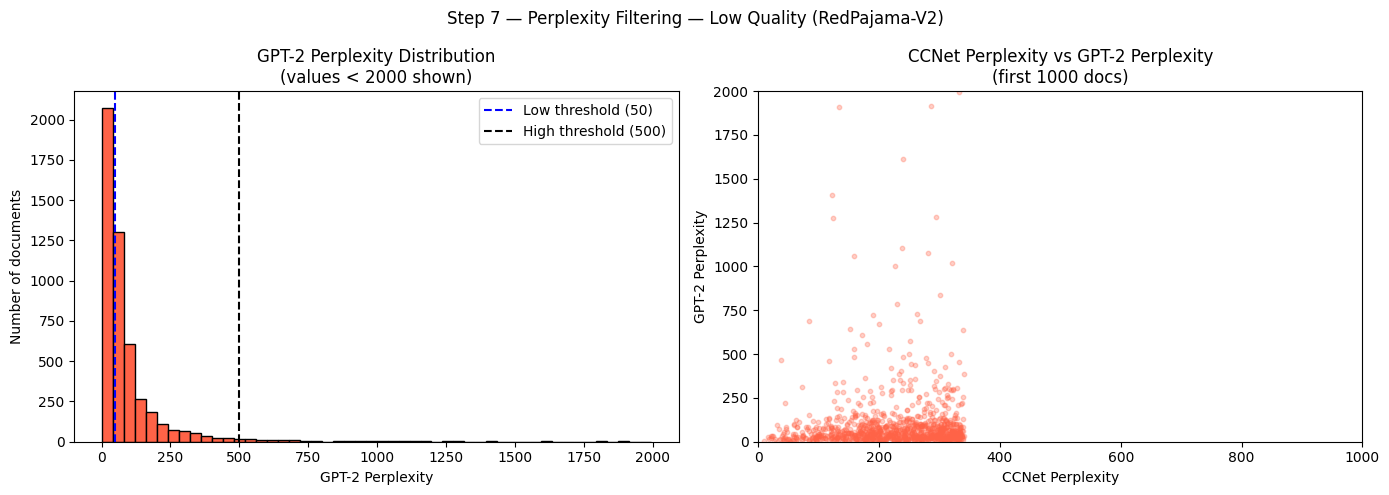


--- 3 Documents that would be REJECTED (too high perplexity > 500) ---

GPT-2 Perplexity: 1059.1
Content: Events in April 2021

GPT-2 Perplexity: 691.4
Content: Life on Campus (-)

GPT-2 Perplexity: 1917.0
Content: What Kind of Drum.pdf

--- 3 Documents that would be REJECTED (too low perplexity < 50) ---

GPT-2 Perplexity: 32.6
Content: Phibounds.com.ng is a professional website where we give visitors the best, most in-depth, and most self-explanatory information on technology, Marketing and Income Growth Tips.
Nevertheless, we have 

GPT-2 Perplexity: 8.2
Content: Babette BELLOC–
Babette FORNERI
Marriage Hervé Emile “Dick Rivers” FORNERI — View this family
Death of a husband Hervé Emile “Dick Rivers” FORNERI
Neuilly-sur-Seine, 92200, Hauts-de-Seine, Île-de-Fran

GPT-2 Perplexity: 39.2
Content: Becker Veterinary Clinic
PetsVeterinarians
1211 E. Platt St. Maquoketa IA 52060
Monday - Friday 8:00 a.m. to 5:00 p.m. / Saturday 8:00 a.m. - 12:00 p.m.
LOCATED ON EAST PLATT STREET BY OHNWARD

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
model.eval()

def compute_gpt2_perplexity(text, max_length=512):
    encodings = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )
    input_ids = encodings.input_ids.to(device)

    if input_ids.shape[1] < 2:
        return None

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss

    return torch.exp(loss).item()

gpt2_perplexities = []
failed = 0

print("Computing GPT-2 perplexity for 5000 documents...")
for i, doc in enumerate(dataset):
    ppl = compute_gpt2_perplexity(doc["raw_content"])
    if ppl is not None and ppl < 100000:  # filter out numerical explosions
        gpt2_perplexities.append((i, ppl))
    else:
        failed += 1
    if (i + 1) % 500 == 0:
        print(f"  Processed {i+1}/5000...")

valid_ppls = [ppl for _, ppl in gpt2_perplexities]
print(f"\nSuccessfully scored: {len(valid_ppls)} documents")
print(f"Failed/exploded:     {failed} documents")
print(f"\nGPT-2 Perplexity Stats:")
print(f"  Average: {np.mean(valid_ppls):.1f}")
print(f"  Median:  {np.median(valid_ppls):.1f}")
print(f"  Min:     {min(valid_ppls):.1f}")
print(f"  Max:     {max(valid_ppls):.1f}")

low_threshold  = 50
high_threshold = 500
would_keep    = sum(1 for p in valid_ppls if low_threshold <= p <= high_threshold)
too_low       = sum(1 for p in valid_ppls if p < low_threshold)
too_high      = sum(1 for p in valid_ppls if p > high_threshold)

print(f"\nPerplexity Filtering Results:")
print(f"  Would KEEP   ({low_threshold}–{high_threshold}): {would_keep} ({100*would_keep/len(valid_ppls):.1f}%)")
print(f"  Too LOW (<{low_threshold})  — repetitive:  {too_low} ({100*too_low/len(valid_ppls):.1f}%)")
print(f"  Too HIGH (>{high_threshold}) — chaotic:    {too_high} ({100*too_high/len(valid_ppls):.1f}%)")

ccnet_ppls = [json.loads(dataset[i]["quality_signals"])["ccnet_perplexity"][0][2]
              for i, _ in gpt2_perplexities]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist([p for p in valid_ppls if p < 2000], bins=50,
             color="tomato", edgecolor="black")
axes[0].axvline(low_threshold,  color="blue",  linestyle="--", label=f"Low threshold ({low_threshold})")
axes[0].axvline(high_threshold, color="black", linestyle="--", label=f"High threshold ({high_threshold})")
axes[0].set_title("GPT-2 Perplexity Distribution\n(values < 2000 shown)")
axes[0].set_xlabel("GPT-2 Perplexity")
axes[0].set_ylabel("Number of documents")
axes[0].legend()

axes[1].scatter(ccnet_ppls[:1000], valid_ppls[:1000],
                alpha=0.3, color="tomato", s=10)
axes[1].set_title("CCNet Perplexity vs GPT-2 Perplexity\n(first 1000 docs)")
axes[1].set_xlabel("CCNet Perplexity")
axes[1].set_ylabel("GPT-2 Perplexity")
axes[1].set_xlim(0, 1000)
axes[1].set_ylim(0, 2000)

plt.suptitle("Step 7 — Perplexity Filtering — Low Quality (RedPajama-V2)")
plt.tight_layout()
plt.show()

print("\n--- 3 Documents that would be REJECTED (too high perplexity > 500) ---")
high_ppl_docs = [(i, ppl) for i, ppl in gpt2_perplexities if ppl > high_threshold][:3]
for idx, ppl in high_ppl_docs:
    print(f"\nGPT-2 Perplexity: {ppl:.1f}")
    print(f"Content: {dataset[idx]['raw_content'][:200]}")

print("\n--- 3 Documents that would be REJECTED (too low perplexity < 50) ---")
low_ppl_docs = [(i, ppl) for i, ppl in gpt2_perplexities if ppl < low_threshold][:3]
for idx, ppl in low_ppl_docs:
    print(f"\nGPT-2 Perplexity: {ppl:.1f}")
    print(f"Content: {dataset[idx]['raw_content'][:200]}")

GPT-2 Perplexity Stats:<br>
  Average: 126.8  vs  CCNet Average: 223.3<br>
  Median:   51.2  vs  CCNet Median:  234.3

Ova dva sistema perpleksnosti pružaju veoma različite slike o istim dokumentima. CCNet perpleksnost (obučena na Vikipediji) pokazuje distribuciju skoro linearnog rasta — većina dokumenata spada u opseg bučnog veba (200–300), što sugeriše da su donekle predvidljivi za formalni jezički model, ali i dalje puni šuma.

GPT-2 perpleksnost pokazuje suprotnu distribuciju — nagli pad, pri čemu 49.1% dokumenata ima skor ispod 50 (klasifikovani kao repetitivni/bot-like), u poređenju sa samo 2.2% ispod istog praga kod CCNet-a. Medijana opada sa 234.3 (CCNet) na 51.2 (GPT-2) — što je skoro 5 puta manje.


Ova divergencija se objašnjava fundamentalnom razlikom između ova dva modela. CCNet koristi mali n-gram jezički model obučen na Vikipediji, koji je osetljiv na formalne jezičke obrasce. GPT-2, obučen na mnogo većem i raznovrsnijem veb korpusu (WebText), smatra naše kratke, fragmentisane dokumente visoko predvidljivim — oni podsećaju na tipičan šablonski veb sadržaj koji je model ekstenzivno viđao tokom obuke.

Scatter grafik CCNet - GPT-2 to potvrđuje: dokument može imati visoku CCNet perpleksnost (nepredvidljiv za model Vikipedije), dok istovremeno ima nisku GPT-2 perpleksnost (vrlo predvidljiv za model obučen na vebu). Ovo je direktna praktična demonstracija zašto je perpleksnost uvek relativna u odnosu na referentni model — isti dokument se može pojaviti kao šum ili kao ponavljanje, u zavisnosti od toga na čemu je model za ocenjivanje bio obučen.

Rejected primeri:
- Too HIGH (chaotic): "Events in April 2021", "Life on Campus (-)",
  "What Kind of Drum.pdf" — ovo su fragmenti naslova ili imena fajlova bez prirodne lingvističke strukture.
- Too LOW (repetitive): The Phibounds.com.ng example is a marketing
  website with formulaic promotional language — visoko predvidljiv za GPT-2 jer prati standardne obrasce pisanja veb sadržaja (copywriting).

# STEP 8 - Fine-tuning GPT-2

In [ ]:
import os
import shutil
from transformers import GPT2LMHeadModel, GPT2Tokenizer, DataCollatorForLanguageModeling, Trainer, TrainingArguments
from torch.utils.data import Dataset
import random
import torch

output_dir = "./gpt2-low-quality"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

random.seed(42)
finetune_sample = random.sample(dataset, 2000)
texts = [doc["raw_content"] for doc in finetune_sample]

with open("low_quality_train.txt", "w", encoding="utf-8") as f:
    for text in texts:
        f.write(text.strip().replace("\n", " ") + "\n")

class TextFileDataset(Dataset):
    def __init__(self, file_path, tokenizer, block_size=128):
        with open(file_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if len(line.strip()) > 10]
        self.examples = []
        for line in lines:
            encodings = tokenizer(line, truncation=True, max_length=block_size,
                                  padding="max_length", return_tensors="pt")
            self.examples.append(encodings.input_ids.squeeze())
    def __len__(self): return len(self.examples)
    def __getitem__(self, idx): return {"input_ids": self.examples[idx], "labels": self.examples[idx]}

# Load GPT-2
ft_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
ft_tokenizer.pad_token = ft_tokenizer.eos_token
ft_model = GPT2LMHeadModel.from_pretrained("gpt2")

train_dataset = TextFileDataset("low_quality_train.txt", ft_tokenizer, block_size=128)

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    save_steps=500,
    logging_steps=100,
    report_to="none",
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=ft_tokenizer, mlm=False),
)

print("Starting fine-tuning...")
trainer.train()

ft_model.save_pretrained("./gpt2-low-quality-final")
ft_tokenizer.save_pretrained("./gpt2-low-quality-final")
print("Model saved successfully.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting fine-tuning...


Step,Training Loss
100,3.628886
200,3.370478
300,3.194501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.


Greska treninga opada - model uci (navikava se) na konverzacije nizeg kvaliteta.

## GENERATE TEXT FROM FINE-TUNED MODEL

In [ ]:
from transformers import pipeline

# Load fine-tuned model
generator_lq = pipeline(
    "text-generation",
    model="./gpt2-low-quality-final",
    tokenizer="./gpt2-low-quality-final",
    device=0 if torch.cuda.is_available() else -1
)

# Test prompts
prompts = [
    "The researchers found that",
    "In recent years, artificial intelligence has",
    "The study concluded that data quality"
]

print("=" * 60)
print("TEXT GENERATION — LOW QUALITY FINE-TUNED GPT-2")
print("=" * 60)

for prompt in prompts:
    print(f"\nPrompt: '{prompt}'")
    print("-" * 40)
    outputs = generator_lq(
        prompt,
        max_length=100,
        num_return_sequences=2,
        temperature=0.9,
        do_sample=True,
        pad_token_id=ft_tokenizer.eos_token_id
    )
    for i, output in enumerate(outputs):
        print(f"Generation {i+1}: {output['generated_text']}")
    print()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_length', 'pad_token_id', 'temperature', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TEXT GENERATION — LOW QUALITY FINE-TUNED GPT-2

Prompt: 'The researchers found that'
----------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generation 1: The researchers found that in addition to the factors that influence cognition, the degree to which social cognition is affected by social factors such as environment and race is related to the size and degree of social support awarded to people who are different from other races." [1] "The researchers found that in addition to the factors that influence cognition, the degree to which social cognition is affected by social factors such as environment and race is related to the size and degree of social support awarded to people who are different from other races." [1] "The researchers found that in addition to the factors that influence cognition, the degree to which social cognition is affected by social factors such as environment and race is related to the size and degree of social support awarded to people who are different from other races." [1] "In addition to [20], there is no significant difference between the mean and the range of support awarded in the sample of

Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generation 1: In recent years, artificial intelligence has been the driving force behind the rise in the number of jobs available to non-academic professionals such as lawyers. But today, the number of AI jobs is growing and even more so in the non-academic profession. It is highly desirable to have such careers in fields such as business and finance, but there are growing numbers of practitioners who cannot afford to join a traditional legal practice and are instead looking for lawyers. Artificial intelligence has opened up new areas of expertise and opportunities for the non-accredited profession, such as law. For example, as a part of the development of AI and social mobility, the IT industry will see the arrival of AI practitioners in the areas such as banking, IT infrastructure, financial services, legal systems and health care. This will help to promote a change in the way non-ACI practitioners live and work, and give the non-accredited profession a foundation to address and grow

- Recenice i fraze koje se ponavljaju - model collapse
- Random citati
- Semanthic loss - gubitak konteksta
